# Simple Linear Regression

Dataset - Weight(independent feature), Height(dependent feature)

```Multicoleanarity``` is a scenario wherein we have 2 to 3 independent features and the correlation b/w those independent features are high, then we can neglect those features which are highly correlated

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('../data/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

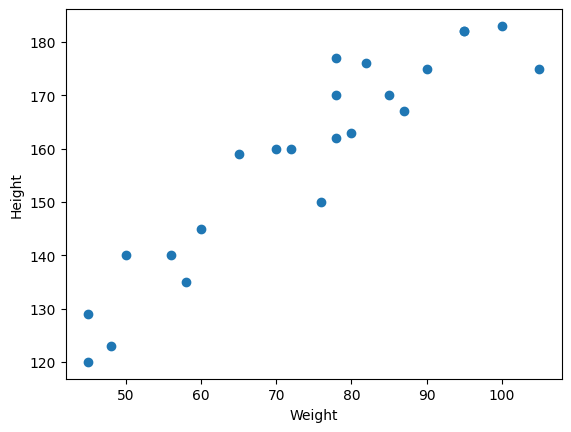

In [3]:
## scatter plot to check features correlation
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [4]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


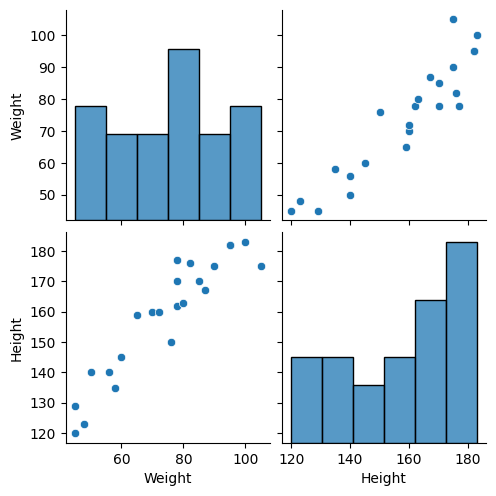

In [5]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [6]:
## Independent and dependent features
X = df[['Weight']]  ### independent feature should be dataframe or 2 dim array
y = df['Height']    ### dependent can be series or 1 dim array


In [7]:
X_series = df['Weight']  ### this is a series, not a dataframe
np.array(X_series).shape

(23,)

In [8]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
X_train.shape

(17, 1)

In [11]:
## Standardization
## apply z-score standardization to the independent feature
## with mean = 0 and std = 1
## Formula: z = (x - mean) / std
from sklearn.preprocessing import StandardScaler

In [12]:
# Data Leakage: We should fit the scaler only on the training data to avoid data leakage, and then transform both the training and test data using the same scaler.
# fit_transform() should be applied only to the training data, and transform() should be applied to the test data.
# the reason is that we want to prevent information from the test set from influencing the scaling of the training data, which could lead to overfitting and unrealistic performance metrics.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [13]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [14]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [15]:
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# This means one unive movement in weight will result in 1.04792503 movement in height value
# when your waight value 0, at what point your line will intersect the y-axis, which is 80.52
print("Coefficient or slope:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


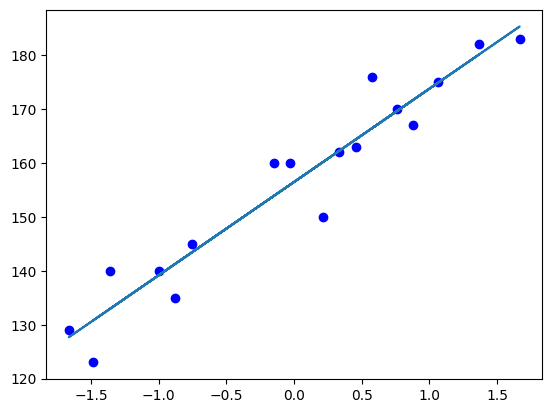

In [17]:
# Plot Training data and plot best fit line
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, regression.predict(X_train))

In [18]:
# Prediction for test data
y_pred = regression.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 9.66512588679501
Mean Squared Error: 114.84069295228699
Root Mean Squared Error: 10.716374991212605


# R square

Formula
```
R^2 = 1 - SSR/SST
```
R^2 = coefficient of determinition SSR = sum of squares of residuals SST = total sum of squares

In [21]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.7360826717981276


Adjusted R^2 = 1 - [(1 - R^2)*(n-1)/(n-k-1)]

where:

R2: The R2 of the model 

n: The number of observations

k: The number of predictor variables



In [22]:
1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.6701033397476595

In [23]:
## OLS (Ordinary Least Squares) method
import statsmodels.api as sm

In [24]:
model = sm.OLS(y_train, X_train).fit()

In [25]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [26]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 01 Apr 2026   Prob (F-statistic):                       0.664
Time:                        14:13:20   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [27]:
## Prediction for new data
regression.predict(scaler.transform([[72]]))

c:\Users\eliza\VSCode\ml-practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])